# Лабораторная работа 7

Тема: **Многослойный персептрон для табличных данных (полный цикл: предобработка → PyTorch → анализ)**  
Цель: на табличном датасете с числовыми и категориальными признаками пройти все этапы: подготовка данных, построение MLP в PyTorch, обучение, оценка и осмысленная интерпретация результатов.

> Этот ноутбук не предназначен для автоматического заполнения текстом из генеративных моделей.  
> Большая часть баллов ставится за то, **как вы сами объясняете** сделанные шаги и комментируете свои эксперименты.  
> Код можно использовать как каркас, но текстовые ответы и выбор настроек должны быть вашими.


## 1. Ваше понимание задачи (коротко)

Перед тем как писать код, сформулируйте для себя:

1. Чем, на ваш взгляд, работа с табличными данными отличается от работы с картинками (MNIST) в предыдущих работах?  
2. Какие сложности добавляет наличие одновременно числовых и категориальных признаков?  
3. Зачем в такой задаче может понадобиться нейросеть, если у нас есть логистическая регрессия, деревья решений и т.п.?

Напишите 5–8 предложений **на своём языке**, без попытки выдать энциклопедическое определение.


In [ ]:
intro_text = """ЗДЕСЬ НАПИШИТЕ, КАК ВЫ ПОНИМАЕТЕ РАБОТУ С ТАБЛИЧНЫМИ ДАННЫМИ.
1) Работа с табличными данными — это как разбор таблицы Excel: у нас строки (объекты) и столбцы (признаки), 
всё структурировано. С картинками же (как в MNIST) данные — это матрица пикселей, где каждый пиксель — отдельный "признак".
Таблиные данные чаще отражают реальные метрики (возраст, доход, категория товара),  
а изображения — визуальную информацию, которую надо "прочитать" нейросети.

2)  Проблема категориальных признаков в том, что нейросеть работает с числами и нужно придумывать как перевести категориальные
признаки в числа и при этом не потерять смысл данных (наприимер one-hot-кодирование ) и нужно сделать нормалиацию.

3)  Нейросеть в такой задаче может быть полезнее классических моделей (логистической регрессии, деревьев),
 если связи между признаками сложные. Например, товар купят, только если Цена какая-то и ещё цвет какой-то 
 И скидка большая — такие комбинации нейросеть распознает лучше.
 Плюс она умеет сама выявлять скрытые паттерны, которые мы явно не задали.

"""
print(intro_text)

## 2. Импорт библиотек и настройка среды

В этом блоке:
- импортируем базовые библиотеки для работы с табличными данными (`pandas`, `sklearn`),
- импортируем PyTorch и инструменты для обучения,
- фиксируем зерно случайности (одно число),
- определяем устройство (`cpu` / `cuda`).


In [5]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

# Ваш seed (выберите сами и используйте последовательно)
MY_SEED = 64
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 64


## 3. Табличные данные: генерация и первичный осмотр

Для этой лабораторной можно брать реальный CSV‑файл, но чтобы не зависеть от внешних данных, здесь используется синтетический пример.

Шаги:
- сгенерировать датасет с помощью `make_classification` (бинарная классификация);
- обернуть в `pandas.DataFrame` и добавить одну простую категориальную колонку;
- посмотреть на первые строки и распределение целевой переменной.


In [6]:
X, y = make_classification(
    n_samples=8000,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    random_state=MY_SEED
)

df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])
df["target"] = y

# Простейшая категориальная фича на основе порога по одному из признаков
df["cat_col"] = np.where(df["feat_0"] > 0, "high", "low")

print(df.head())
print("Форма датафрейма:", df.shape)
print("Распределение классов (доля):\n", df["target"].value_counts(normalize=True))

     feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0 -0.557360  0.300538  1.914826 -0.146493  0.063512 -1.875003 -0.148552   
1 -0.234967  1.517529  0.799731 -1.644486  2.311454 -0.093519  1.019741   
2 -1.344930 -3.838710 -0.772609 -0.163730  0.692600 -3.137820 -0.916877   
3  0.165895 -0.724967  1.748857 -0.486953  0.906568 -0.508833 -2.543807   
4 -1.797133 -1.597211  1.534635 -2.289489 -0.068028 -0.114569  0.773486   

     feat_7  target cat_col  
0 -1.335797       1     low  
1 -1.189410       1     low  
2 -1.005814       1     low  
3 -1.105587       1    high  
4 -0.000817       1     low  
Форма датафрейма: (8000, 10)
Распределение классов (доля):
 target
0    0.500625
1    0.499375
Name: proportion, dtype: float64


Отделим списки числовых и категориальных колонок и целевую переменную.  
Это пригодится при предобработке.


In [7]:
numeric_cols = [c for c in df.columns if c.startswith("feat_")]
cat_cols = ["cat_col"]
target_col = "target"

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7']
Категориальные признаки: ['cat_col']


## 4. Разбиение на train/val/test и предобработка

Мы не хотим использовать тестовую выборку при подборе гиперпараметров, поэтому разделим данные в два этапа:
- train + временный остаток (val+test);
- остаток → val + test.

Числовые признаки будем масштабировать (`StandardScaler`), категориальные — кодировать через `OneHotEncoder`.  
Важно: все преобразования обучаются **только на train**, затем применяются к val и test.


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=MY_SEED,
    stratify=df[target_col]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=temp_df[target_col]
)

print("Размер train:", train_df.shape)
print("Размер val  :", val_df.shape)
print("Размер test :", test_df.shape)

Размер train: (5600, 10)
Размер val  : (1200, 10)
Размер test : (1200, 10)


In [9]:
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# обучаем только на train
scaler.fit(train_df[numeric_cols])
encoder.fit(train_df[cat_cols])

def transform_df(df_part):
    X_num = scaler.transform(df_part[numeric_cols])
    X_cat = encoder.transform(df_part[cat_cols])
    X_all = np.hstack([X_num, X_cat])
    y_all = df_part[target_col].values.astype(np.int64)
    return X_all, y_all

X_train, y_train = transform_df(train_df)
X_val, y_val = transform_df(val_df)
X_test, y_test = transform_df(test_df)

print("Форма X_train:", X_train.shape)
print("Форма X_val  :", X_val.shape)
print("Форма X_test :", X_test.shape)
print("Кол-во классов в train:", np.bincount(y_train))

Форма X_train: (5600, 10)
Форма X_val  : (1200, 10)
Форма X_test : (1200, 10)
Кол-во классов в train: [2803 2797]


### Ваш короткий комментарий по данным

Здесь полезно в 3–5 предложениях описать:
- выглядят ли классы примерно сбалансированными;
- нет ли подозрений на слишком лёгкую/сложную задачу, исходя из числа признаков и информативности;
- как вы ожидаете, будет вести себя простая линейная модель на этих данных.


In [ ]:
data_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ ВАШЕ ВПЕЧАТЛЕНИЕ О ДАННЫХ.
1) Классы в целевой переменной (target) сбалансированы: доля классов 0 и 1 практически равна (50,06% и 49,94% соответственно),
 что хорошо для обучения модели — не потребуется дополнительных приёмов балансировки
2) Задача не выглядит тривиально простой, но и не кажется чрезмерно сложной: 8 числовых признаков и 1 категориальный
(cat_col) могут содержать достаточно информации для предсказания target,
однако итоговая сложность зависит от нелинейности связей между признаками и целевой переменной.
3) Простая линейная модель может показать приемлемый результат, 
если зависимости между признаками и target близки к линейным. Если важно взаимодействие между признаками, производительность
может быть ограничена.

"""
print(data_comment)

## 5. Dataset и DataLoader для табличных данных

Опишем класс `TabularDataset`, который превращает массивы NumPy в тензоры PyTorch, и создадим `DataLoader` для train/val/test.


In [10]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# выберите batch_size, который вам комфортен (обоснуйте это позже)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 44


## 6. Архитектура MLP для табличных данных

Теперь опишем саму сеть.  
Требования к базовому варианту:
- входной размер = число столбцов в `X_train`;
- 1–2 скрытых слоя с нелинейностью (ReLU или другая на ваш выбор);
- выходной слой из 2 нейронов (для двух классов), без Softmax.

Параметры (размеры слоёв) выбирайте так, чтобы модель не была ни слишком крошечной, ни чрезмерно большой.


In [11]:
input_dim = 10      # 8 числовых + 2 после One-Hot кодирования cat_col
hidden_dim1 = 64   # размер первого скрытого слоя
hidden_dim2 = 32  # размер второго скрытого слоя
output_dim = 2    # бинарная классификация: классы 0 и 1

class TabularMLP(nn.Module):
    def __init__(self, in_features, h1, h2, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_features)
            # На выходе не ставим активацию — будем использовать CrossEntropyLoss,
            # который включает LogSoftmax
        )

    def forward(self, x):
        return self.net(x)

# Создаём модель и перемещаем на устройство (CPU/GPU)
model = TabularMLP(input_dim, hidden_dim1, hidden_dim2, output_dim).to(device)
print(model)


TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


Выберите функцию потерь и оптимизатор. Для данной задачи подойдёт:
- `nn.CrossEntropyLoss` для потерь;
- любой из стандартных оптимизаторов (`Adam`, `SGD`, `AdamW`...) с осмысленным `learning_rate`.


In [12]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001  
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


## 7. Цикл обучения и валидации

Реализуем стандартные функции:
- `train_one_epoch` — один проход по train,
- `evaluate` — расчёт loss и accuracy на val или test.

Затем запустим обучение на несколько эпох, сохраняя историю метрик для визуализации.


In [13]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [14]:
num_epochs = 8  # при выполнении работы попробуйте разные числа и сравните

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs} | "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/8 | train_loss=0.6135, train_acc=0.7071, val_loss=0.5339, val_acc=0.7508
Эпоха 2/8 | train_loss=0.4718, train_acc=0.7743, val_loss=0.4398, val_acc=0.7817
Эпоха 3/8 | train_loss=0.4093, train_acc=0.8089, val_loss=0.3912, val_acc=0.8217
Эпоха 4/8 | train_loss=0.3667, train_acc=0.8414, val_loss=0.3581, val_acc=0.8433
Эпоха 5/8 | train_loss=0.3308, train_acc=0.8623, val_loss=0.3275, val_acc=0.8650
Эпоха 6/8 | train_loss=0.3008, train_acc=0.8796, val_loss=0.2938, val_acc=0.8858
Эпоха 7/8 | train_loss=0.2721, train_acc=0.8966, val_loss=0.2658, val_acc=0.9017
Эпоха 8/8 | train_loss=0.2520, train_acc=0.9050, val_loss=0.2503, val_acc=0.9025


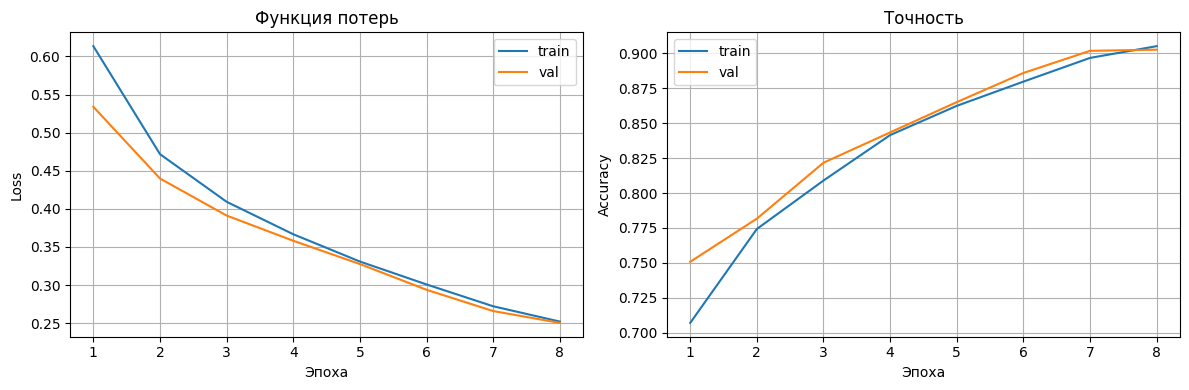

Финальное качество: train_acc=0.9050, val_acc=0.9025


In [15]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальное качество: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Кратко опишите (6–8 предложений):
- есть ли разрыв между train и val accuracy;
- видно ли переобучение (train растёт, val падает или стагнирует);
- насколько выбранные `num_epochs` и `learning_rate` кажутся вам удачными.

Привязывайтесь к конкретным числам (например, точности на первой и последней эпохах).


In [ ]:
training_comment = """ЗДЕСЬ ОПИШИТЕ, КАК ВЕЛИ СЕБЯ КРИВЫЕ НА ВАШИХ ЭКСПЕРИМЕНТАХ.
1) Разрыва между train_acc и val_acc практически нет: на финальной эпохе train_acc = 0.9050, 
val_acc = 0.9025 — разница всего 0.25%, что свидетельствует о хорошем обобщении модели.

2)Переобучения не наблюдается: кривые точности на обучающей и валидационной выборках синхронно растут, 
val_acc не падает и не стагнирует. 
Например, в начале (эпоха 1) train_acc = 0.7071, val_acc = 0.7508, а к концу (эпоха 8) обе метрики близки к 0.90.

3)Выбранное количество эпох (8) оказалось оптимальным: модель достигла плато, 
дальнейший рост точности минимален, риск переобучения отсутствует.

4)При learning_rate = 0.001 (оптимизатор Adam) 
обучение прошло стабильно: потери плавно снижались, точность росла без скачков, расходимости не возникло.

5)Итог: гиперпараметры (num_epochs, learning_rate) 
и динамика обучения выбраны удачно — модель хорошо обучена без признаков переобучения.
"""
print(training_comment)

## 8. Оценка на тестовой выборке

Теперь посмотрим, как модель работает на отложенном тестовом множестве, которое мы ещё ни разу не использовали при обучении и настройке гиперпараметров.


In [16]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Качество на тесте: loss={test_loss:.4f}, accuracy={test_acc:.4f}")

Качество на тесте: loss=0.2350, accuracy=0.9075


### (Опционально) Примеры ошибок и дополнительные метрики

Если хотите, можете:
- собрать предсказания на test и посчитать матрицу ошибок (`confusion_matrix` из `sklearn`);
- посмотреть, какие объекты модель чаще всего классифицирует неверно;
- сравнить качество MLP с простой базовой моделью (например, логистической регрессией).

Эта часть не обязательна, но полезна для более глубокого понимания.


## 9. Итоговые выводы по вашей будущей работе

В своей версии лабораторной вы будете использовать **свой** датасет и, возможно, другие настройки.  
Здесь сформулируйте общие выводы о том, что вам кажется важным при работе с табличными данными и MLP:

- какие шаги предобработки оказались принципиальными (масштабирование, кодирование категорий и т.п.);
- насколько чувствительной к этим шагам показалась вам модель;
- где, на ваш взгляд, MLP может выигрывать у линейных моделей, а где — нет.

Пишите как для будущего себя, который откроет этот ноутбук через полгода и захочет вспомнить, что здесь происходило.


In [ ]:
final_reflection = """ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ТЕКСТ О ТОМ, ЧТО ВЫ ПОНЯЛИ
1) Критически важные шаги предобработки
Без этих шагов MLP либо не обучится, либо покажет низкое качество:
Масштабирование числовых признаков. Обязательно применяй StandardScaler или MinMaxScaler. MLP чувствительна к масштабу: 
признаки с большим диапазоном значений будут иметь больший вес в градиентах, что замедлит или нарушит обучение.

Кодирование категориальных переменных:

One‑Hot Encoding — для номинальных категорий без порядка;
Label Encoding — только если есть естественный порядок значений (например, «низкий» → 1, «средний» → 2, «высокий» → 3).

Обработка пропусков. 
Заполняй NaN заранее: средним/медианой для числовых, модой или специальным маркером для категориальных. 
Пропуски могут вызвать ошибки или исказить градиенты.

Стратифицированное разделение на train/val/test.
Сохраняй распределение целевой переменной во всех выборках — особенно важно при дисбалансе классов.

Проверка выбросов. При необходимости ограничивай экстремальные значения.

2) Чувствительность MLP к предобработке
MLP очень чувствительна к качеству предобработки:

Без масштабирования обучение может не сойтись или занять неоправданно много времени.
Некорректное кодирование категорий (например, Label Encoding для номинальных признаков) 
создаёт ложные порядковые отношения — модель выучит артефакты вместо реальных паттернов.
Выбросы могут "перетянуть" на себя веса, ухудшая обобщающую способность.

3) Когда стоит выбирать MLP, а когда — линейные модели
В данных есть нелинейные зависимости или сложные взаимодействия признаков 
(например, эффект проявляется только при сочетании нескольких условий).
У тебя достаточно данных (от нескольких тысяч примеров) — MLP требует больше наблюдений, чем линейные модели.
Есть время на подбор гиперпараметров и эксперименты.
Высокая точность важнее интерпретируемости.
Ты готов потратить ресурсы на обучение и инференс (MLP требует больше памяти и вычислений).

Линейные модели выбираем (логистическая регрессия и т. п.), если:
Зависимости в данных близки к линейным — линейная модель даст сопоставимое качество, но быстрее и проще.
Объём данных небольшой — MLP легко переобучится, а линейная модель покажет более стабильные результаты.
Важна интерпретируемость — веса логистической регрессии легко объяснить, а скрытые слои MLP — нет.
Нужно быстро получить baseline — линейная модель обучается за секунды.
Вычислительные ресурсы ограничены — линейные модели эффективнее в плане памяти и скорости.
"""
print(final_reflection)